In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

$$y = \frac{1}{n}\sum_ix_i$$
$$(\Delta y)^2 = \frac{1}{n^2}\sum_i(\Delta x)^2$$

In [5]:
import os
stitles=[]
sfiles = os.listdir("runplot")
sfolder = "runplot/"
for i in range(len(sfiles)):
    if "datai" in sfiles[i] and "copy" not in sfiles[i]:
        stitles.append(sfiles[i].split(".np")[0].split("atai_")[1])
vlen = len(stitles)
sflist=[]
sdatalist=[]
atoms=2000
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
thermsteps = 801
thermvel = 100*(3*kb*Temp/(0.001*MSI))**0.5
for i in range(vlen):
    sdatalist.append(np.loadtxt(sfolder+"datai_{}.np".format(stitles[i])))
    sflist.append(np.loadtxt(sfolder+"tempfarr_{}.np".format(stitles[i])))

# Plot temp and energy over time

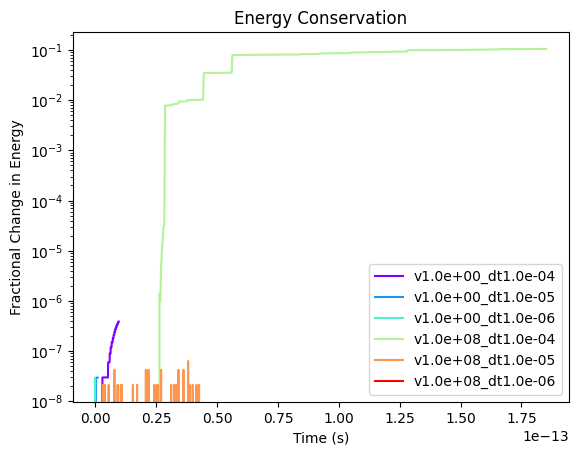

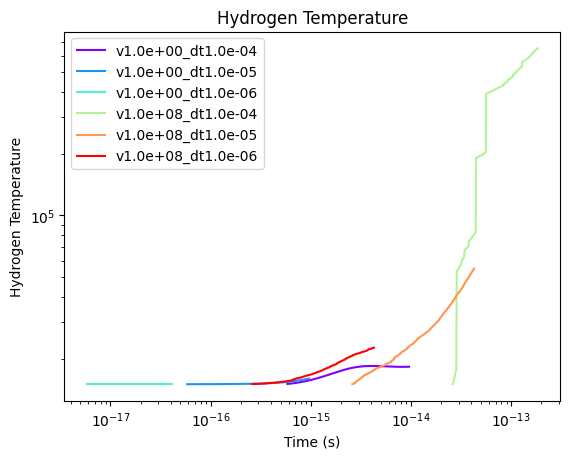

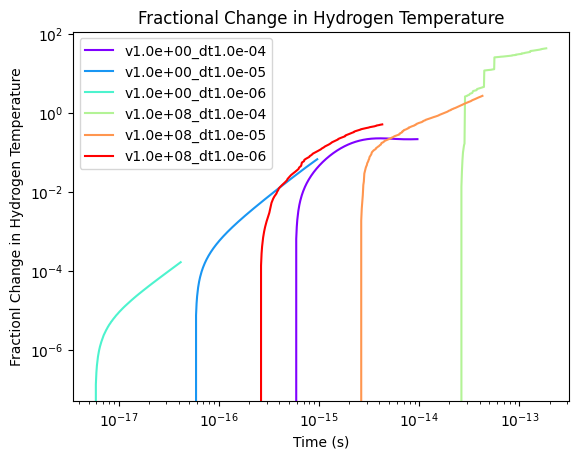

In [16]:
from matplotlib import cm
colors = cm.rainbow(np.linspace(0, 1, vlen))
plt.title("Energy Conservation")
for i in range(vlen):
    plt.plot(sdatalist[i][:,0],np.abs(sdatalist[i][:,4]/sdatalist[i][0,4]-1),color=colors[i],label=stitles[i])
plt.legend()
plt.xlabel("Time (s)")
plt.yscale("log")
plt.ylabel("Fractional Change in Energy")
plt.show()
plt.title("Hydrogen Temperature")
for i in range(vlen):
    plt.plot(sdatalist[i][:,0],sdatalist[i][:,2],color=colors[i],label=stitles[i])
plt.legend()
plt.xlabel("Time (s)")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("Hydrogen Temperature")
plt.show()
plt.title("Fractional Change in Hydrogen Temperature")
for i in range(vlen):
    plt.plot(sdatalist[i][:,0],sdatalist[i][:,2]/sdatalist[i][0,2]-1,color=colors[i],label=stitles[i])
plt.legend()
plt.yscale("log")
plt.xlabel("Time (s)")
# plt.yscale("log")
plt.xscale("log")
plt.ylabel("Fractionl Change in Hydrogen Temperature")
plt.show()

$$v = A\exp(-t/\tau)$$
$$a = -\frac{A}{\tau}\exp(-t/\tau)$$


$$(\Delta a)^2 = (2\frac{A\exp(-t/\tau)}{\tau^2})^2(\Delta \tau)^2+(\frac{\exp(-t/\tau)}{\tau})^2(\Delta A)^2$$

# Unforced Plot All

1260
1260


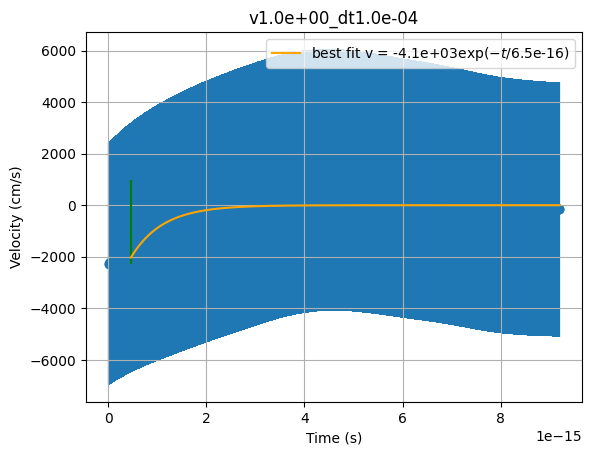

1259
1259


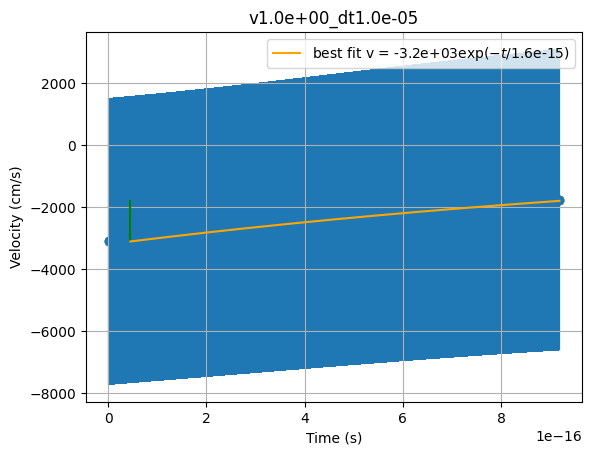

541
541


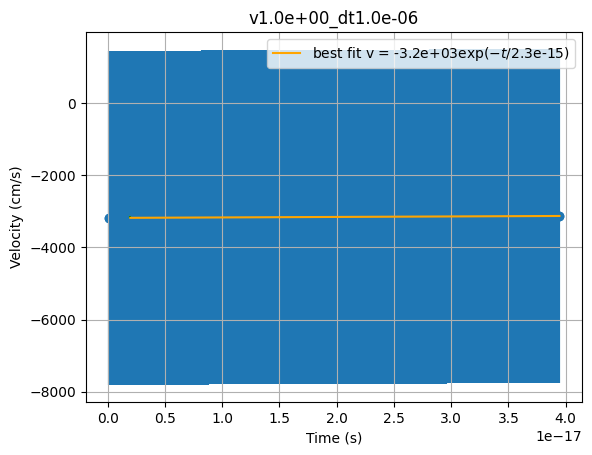

536
536


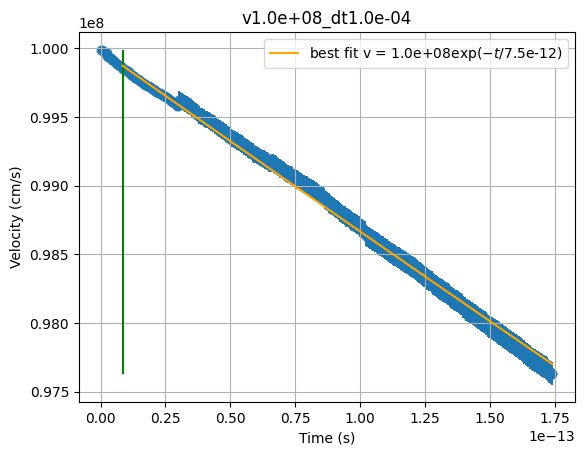

1246
1246


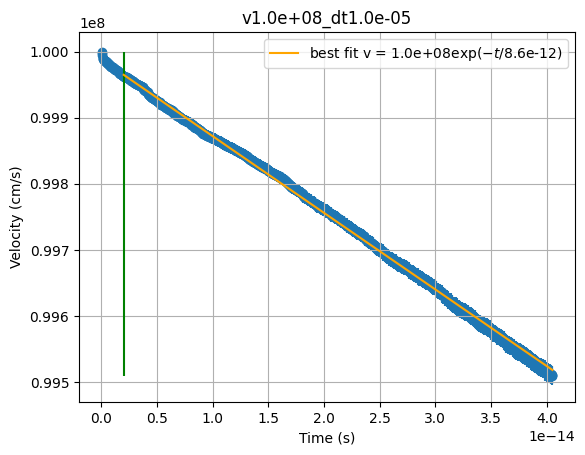

1255
1255


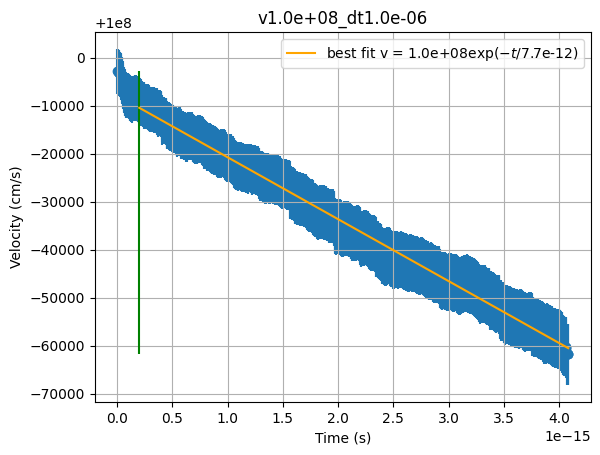

In [25]:
from scipy.optimize import curve_fit
frac = 0.005 #fraction of velocity change to trim
trimarr = np.zeros(len(sflist),dtype=np.int64)
for i in range(len(sflist)):
    # trimarr[i] = np.min([np.argmin(np.abs(sflist[i][:,0]-(1-frac)*sflist[i][1,0])),int(0.9*len(sflist[i][:,0]))])
    trimarr[i] = int(0.05*len(sflist[i][:,0]))
bestfits = np.zeros((vlen,5))
# bestfits[:,0] = varr
colors2 = cm.rainbow(np.linspace(0, 1, vlen))
def exp(time,m,b):
    return b*np.exp(-time/m)

for i in range(vlen):
    dt = sdatalist[i][1,0]-sdatalist[i][0,0]
    plotlen = len(sflist[i][:,0])
    timearr = np.arange(0,plotlen*dt-0.001*dt,dt)
    starti = trimarr[i]
    mguess = 1e-14
    bguess = sflist[i][1,0]
    
    plt.figure()
    plt.title(stitles[i])
    plt.grid(zorder=0)
    print(len(timearr))
    print(len(sflist[i][:,0]))
    plt.errorbar(timearr[1:],sflist[i][1:,0],yerr=sflist[i][1:,1],fmt="o",zorder=1)
    plt.vlines(timearr[starti],ymin=np.min(sflist[i][1:,0]),ymax = np.max(sflist[i][1:,0]),color="green")
    popt, pcov = curve_fit(exp,timearr[starti:],sflist[i][starti:,0],sigma =sflist[i][starti:,1],p0=[mguess,bguess],absolute_sigma=True)
    errors = np.sqrt(np.diag(pcov))
    bestfits[i,1:3] = popt
    bestfits[i,3:] = errors
    plt.plot(timearr[starti:],exp(timearr[starti:],*popt),color="orange",zorder=10,label=r"best fit v = {:.1e}$\exp(-t/${:.1e}$)$".format(bestfits[i,2],bestfits[i,1]))
    # results[i,:] = [np.mean(flist[i][:,0]),((np.sum(np.square(flist[i][:,1])))**0.5)/len(flist[i][:,1])]
    plt.legend()
    plt.xlabel(r"Time (s)")
    plt.ylabel(r"Velocity (cm/s)")
    plt.show()



$$ a = v/\tau$$
$$ \Delta a = \frac{v}{\tau^2}\Delta \tau$$

C:\Users\shaoq\AppData\Local\Temp\ipykernel_23724\941790429.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


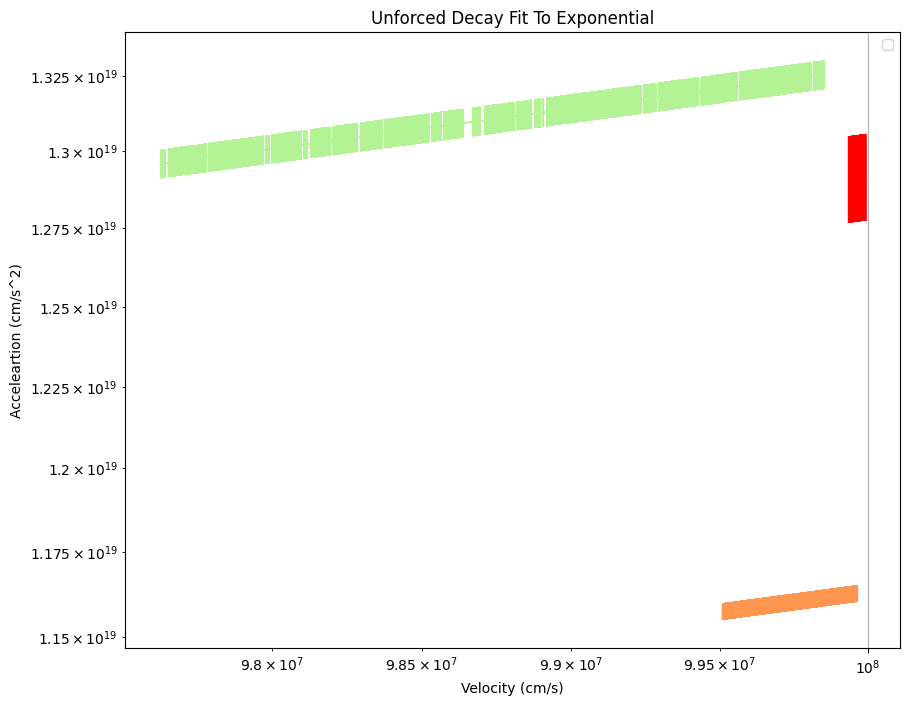

In [ ]:
plt.figure(figsize=(10,8))
colors = cm.rainbow(np.linspace(0, 1, vlen))
plt.title(r"Unforced Decay Fit To Exponential")
plt.grid(zorder=0)
lenfit = 0
for i in range(3,6):
    starti = trimarr[i]
    # plt.scatter(flist[i][starti:,0],flist[i][starti:,0]/bestfits[i,1],color=colors[i])
    plt.errorbar(sflist[i][starti:,0],sflist[i][starti:,0]/bestfits[i,1],yerr = np.abs(bestfits[i,3]*sflist[i][starti:,0]/(bestfits[i,1]**2)),color=colors[i],label=stitles[i])
    lenfit += len(sflist[i][starti:,0])
fitarr = np.zeros((lenfit,3))
currenti = 0
# for i in range(vlen):
#     starti = trimarr[i]
#     currentlen = len(sflist[i][starti:,0])
#     fitarr[currenti:currenti+currentlen,0] = sflist[i][starti:,0]
#     fitarr[currenti:currenti+currentlen,1] = sflist[i][starti:,0]/bestfits[i,1]
#     fitarr[currenti:currenti+currentlen,2] = bestfits[i,3]*sflist[i][starti:,0]/(bestfits[i,1]**2)
#     currenti += currentlen
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"Velocity (cm/s)")
plt.ylabel(r"Acceleartion (cm/s^2)")
plt.show()


# Unforced Find Ideal Window Size

[    1     1     1     1     1  5057    32    39   170   340   482  1425
  1003   504  3503  3521 10312 10250  4063 10310]
[3.08220e-19 6.16440e-19 9.24660e-19 1.23288e-18 1.54110e-18 1.84932e-18
 2.15754e-18 2.46576e-18 2.77398e-18 3.08220e-18 3.39042e-18 3.69864e-18
 4.00686e-18 4.31508e-18 4.62330e-18 4.93152e-18 5.23974e-18 5.54796e-18
 5.85618e-18 6.16440e-18]


C:\Users\shaoq\AppData\Local\Temp\ipykernel_24040\2697672405.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp,timearr[starti:starti+windowsizes[j]],flist[i][starti:starti+windowsizes[j],0],sigma =flist[i][starti:starti+windowsizes[j],1],p0=popt,absolute_sigma=True)


10
[1.71130881e-14 3.57735904e+02]


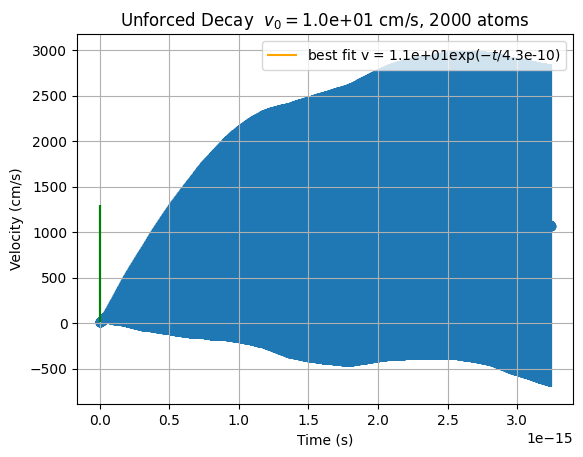

[3.08220e-19 6.16440e-19 9.24660e-19 1.23288e-18 1.54110e-18 1.84932e-18
 2.15754e-18 2.46576e-18 2.77398e-18 3.08220e-18 3.39042e-18 3.69864e-18
 4.00686e-18 4.31508e-18 4.62330e-18 4.93152e-18 5.23974e-18 5.54796e-18
 5.85618e-18 6.16440e-18]
10
[1.71130881e-14 3.57735904e+02]


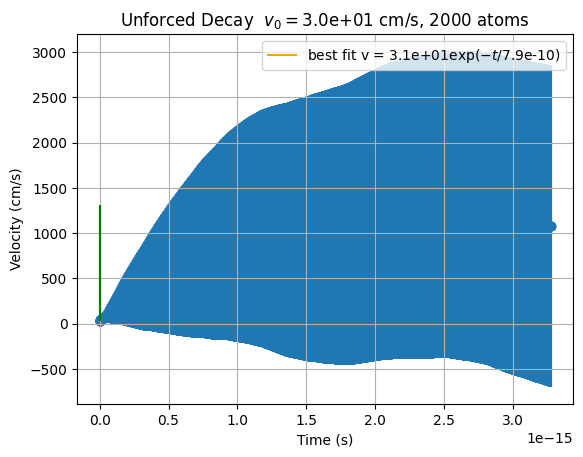

[3.08220e-19 6.16440e-19 9.24660e-19 1.23288e-18 1.54110e-18 1.84932e-18
 2.15754e-18 2.46576e-18 2.77398e-18 3.08220e-18 3.39042e-18 3.69864e-18
 4.00686e-18 4.31508e-18 4.62330e-18 4.93152e-18 5.23974e-18 5.54796e-18
 5.85618e-18 6.16440e-18]


C:\Users\shaoq\AppData\Local\Temp\ipykernel_24040\2697672405.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp,timearr[starti:starti+20],flist[i][starti:starti+20,0],sigma =flist[i][starti:starti+20,1],p0=[mguess,bguess],absolute_sigma=True)


10
[1.71130881e-14 3.57735904e+02]


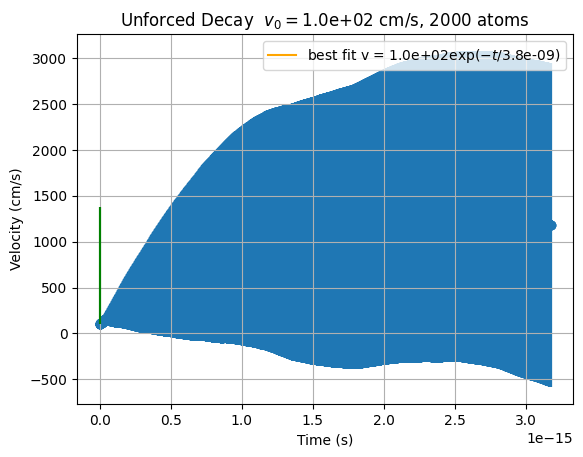

[3.08220e-19 6.16440e-19 9.24660e-19 1.23288e-18 1.54110e-18 1.84932e-18
 2.15754e-18 2.46576e-18 2.77398e-18 3.08220e-18 3.39042e-18 3.69864e-18
 4.00686e-18 4.31508e-18 4.62330e-18 4.93152e-18 5.23974e-18 5.54796e-18
 5.85618e-18 6.16440e-18]
10
[1.71130881e-14 3.57735904e+02]


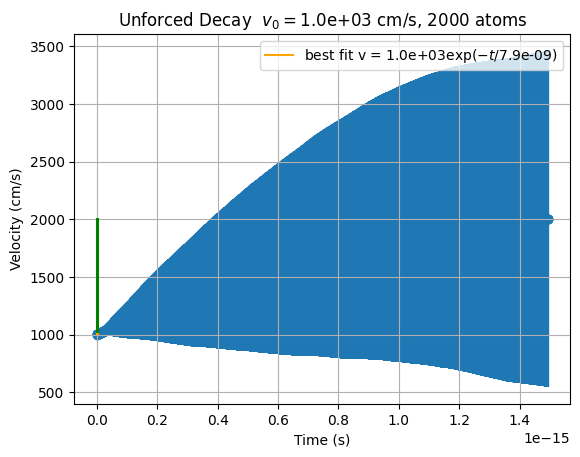

[3.08220e-19 6.16440e-19 9.24660e-19 1.23288e-18 1.54110e-18 1.84932e-18
 2.15754e-18 2.46576e-18 2.77398e-18 3.08220e-18 3.39042e-18 3.69864e-18
 4.00686e-18 4.31508e-18 4.62330e-18 4.93152e-18 5.23974e-18 5.54796e-18
 5.85618e-18 6.16440e-18]
10
[1.71130881e-14 3.57735904e+02]


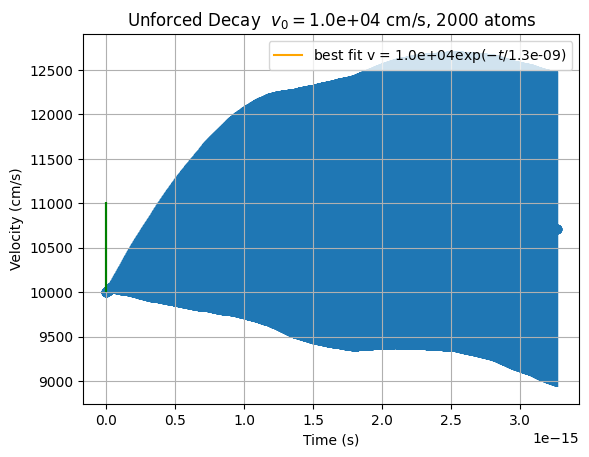

[1.55866854e-15 1.55897676e-15 1.55928498e-15 1.55959320e-15
 1.55990142e-15 1.56020964e-15 1.56051786e-15 1.56082608e-15
 1.56113430e-15 1.56144252e-15 1.56175074e-15 1.56205896e-15
 1.56236718e-15 1.56267540e-15 1.56298362e-15 1.56329184e-15
 1.56360006e-15 1.56390828e-15 1.56421650e-15 1.56452472e-15]
5580
[1.71130881e-14 3.57735904e+02]


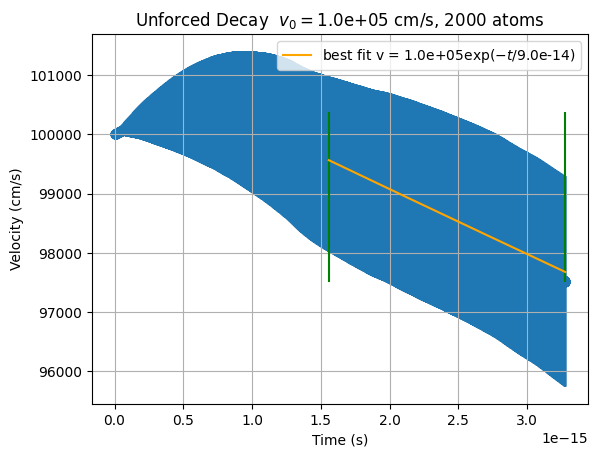

[9.498880e-16 9.795720e-16 1.009256e-15 1.038940e-15 1.068624e-15
 1.098308e-15 1.127992e-15 1.157676e-15 1.187360e-15 1.217044e-15
 1.246728e-15 1.276412e-15 1.306096e-15 1.335780e-15 1.365464e-15
 1.395148e-15 1.424832e-15 1.454516e-15 1.484200e-15 1.513884e-15]
7580
[1.71130881e-14 3.57735904e+02]


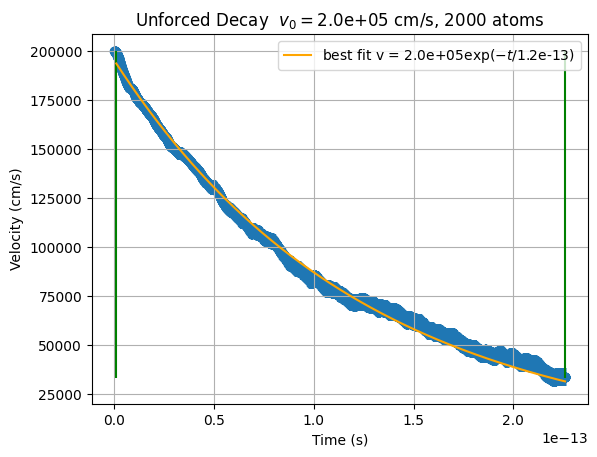

[7.717710e-16 7.915600e-16 8.113490e-16 8.311380e-16 8.509270e-16
 8.707160e-16 8.905050e-16 9.102940e-16 9.300830e-16 9.498720e-16
 9.696610e-16 9.894500e-16 1.009239e-15 1.029028e-15 1.048817e-15
 1.068606e-15 1.088395e-15 1.108184e-15 1.127973e-15 1.147762e-15]
7610
[1.71130881e-14 3.57735904e+02]


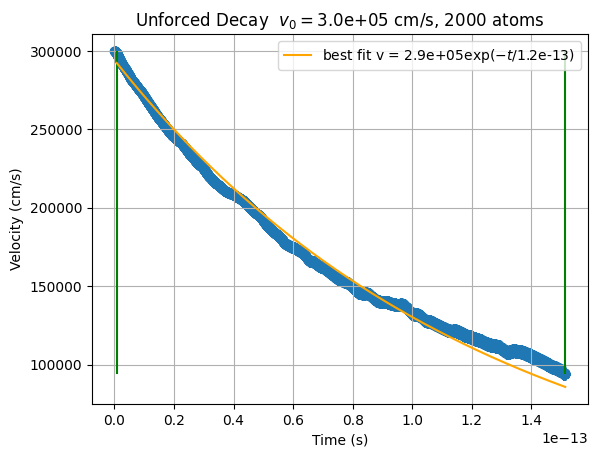

[1.0092390e-15 1.0151757e-15 1.0211124e-15 1.0270491e-15 1.0329858e-15
 1.0389225e-15 1.0448592e-15 1.0507959e-15 1.0567326e-15 1.0626693e-15
 1.0686060e-15 1.0745427e-15 1.0804794e-15 1.0864161e-15 1.0923528e-15
 1.0982895e-15 1.1042262e-15 1.1101629e-15 1.1160996e-15 1.1220363e-15]
7440
[1.71130881e-14 3.57735904e+02]


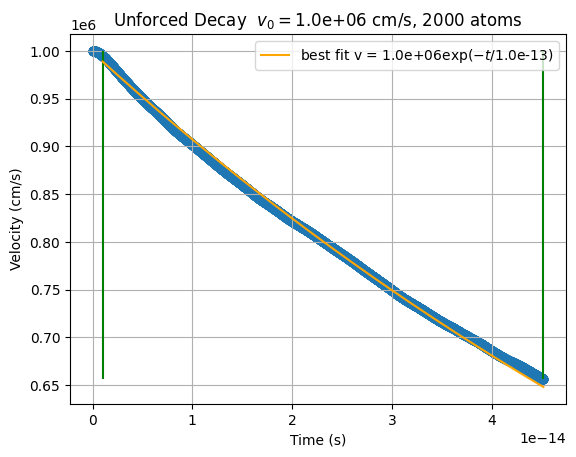

[1.0092560e-15 1.0122244e-15 1.0151928e-15 1.0181612e-15 1.0211296e-15
 1.0240980e-15 1.0270664e-15 1.0300348e-15 1.0330032e-15 1.0359716e-15
 1.0389400e-15 1.0419084e-15 1.0448768e-15 1.0478452e-15 1.0508136e-15
 1.0537820e-15 1.0567504e-15 1.0597188e-15 1.0626872e-15 1.0656556e-15]
7150
[1.71130881e-14 3.57735904e+02]


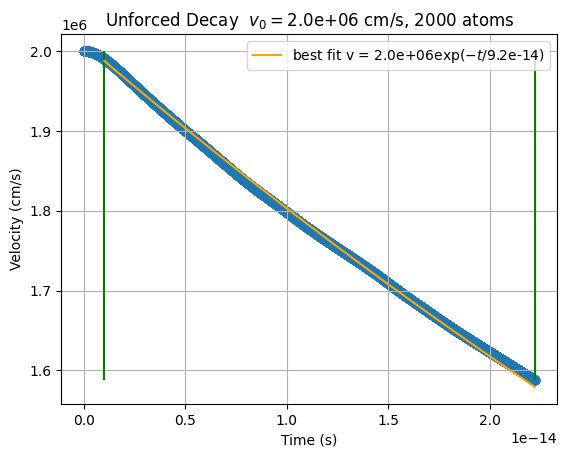

[9.538298e-16 9.558087e-16 9.577876e-16 9.597665e-16 9.617454e-16
 9.637243e-16 9.657032e-16 9.676821e-16 9.696610e-16 9.716399e-16
 9.736188e-16 9.755977e-16 9.775766e-16 9.795555e-16 9.815344e-16
 9.835133e-16 9.854922e-16 9.874711e-16 9.894500e-16 9.914289e-16]
6940
[1.71130881e-14 3.57735904e+02]


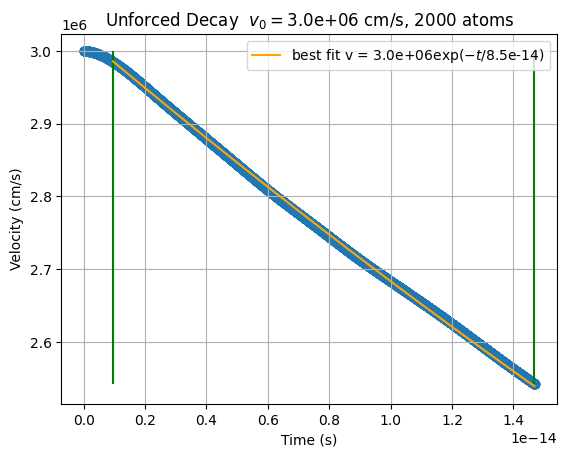

[8.4597975e-16 8.4657342e-16 8.4716709e-16 8.4776076e-16 8.4835443e-16
 8.4894810e-16 8.4954177e-16 8.5013544e-16 8.5072911e-16 8.5132278e-16
 8.5191645e-16 8.5251012e-16 8.5310379e-16 8.5369746e-16 8.5429113e-16
 8.5488480e-16 8.5547847e-16 8.5607214e-16 8.5666581e-16 8.5725948e-16]
650
[1.71130881e-14 3.57735904e+02]


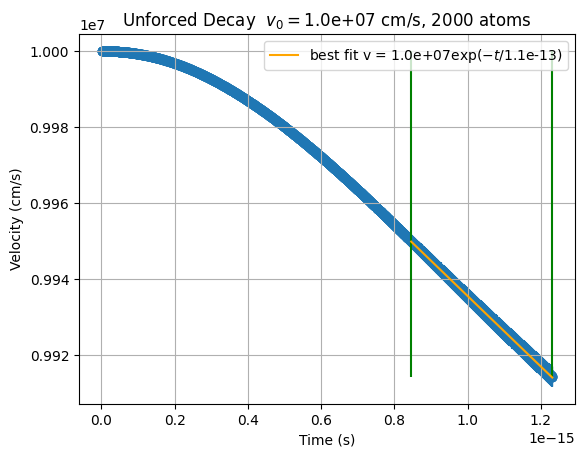

[2.97724502e-16 2.98021336e-16 2.98318170e-16 2.98615004e-16
 2.98911838e-16 2.99208672e-16 2.99505506e-16 2.99802340e-16
 3.00099174e-16 3.00396008e-16 3.00692842e-16 3.00989676e-16
 3.01286510e-16 3.01583344e-16 3.01880178e-16 3.02177012e-16
 3.02473846e-16 3.02770680e-16 3.03067514e-16 3.03364348e-16]
190
[1.71130881e-14 3.57735904e+02]


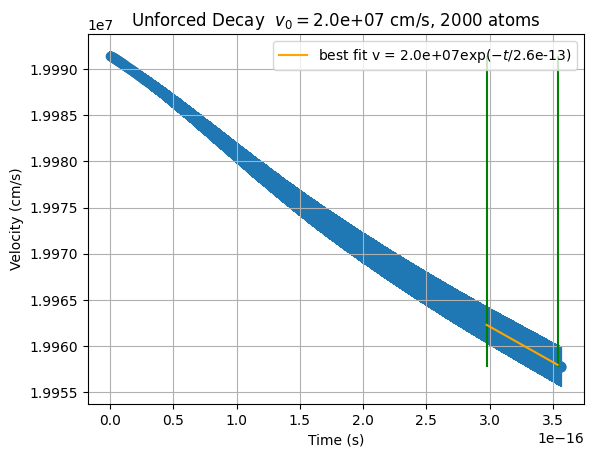

[9.97360560e-17 9.99339450e-17 1.00131834e-16 1.00329723e-16
 1.00527612e-16 1.00725501e-16 1.00923390e-16 1.01121279e-16
 1.01319168e-16 1.01517057e-16 1.01714946e-16 1.01912835e-16
 1.02110724e-16 1.02308613e-16 1.02506502e-16 1.02704391e-16
 1.02902280e-16 1.03100169e-16 1.03298058e-16 1.03495947e-16]
190
[1.71130881e-14 3.57735904e+02]


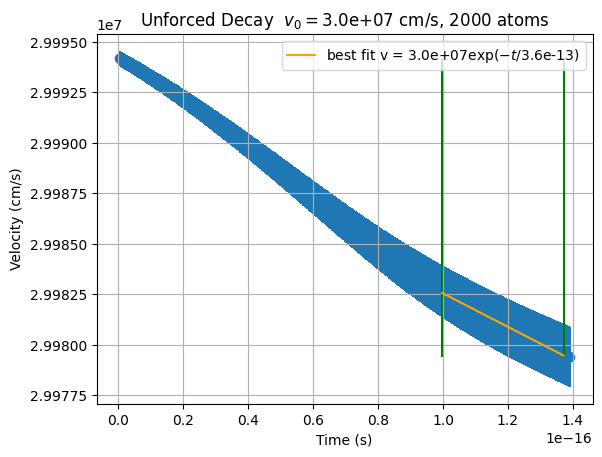

[5.1988023e-17 5.2002864e-17 5.2017705e-17 5.2032546e-17 5.2047387e-17
 5.2062228e-17 5.2077069e-17 5.2091910e-17 5.2106751e-17 5.2121592e-17
 5.2136433e-17 5.2151274e-17 5.2166115e-17 5.2180956e-17 5.2195797e-17
 5.2210638e-17 5.2225479e-17 5.2240320e-17 5.2255161e-17 5.2270002e-17]
190
[1.71130881e-14 3.57735904e+02]


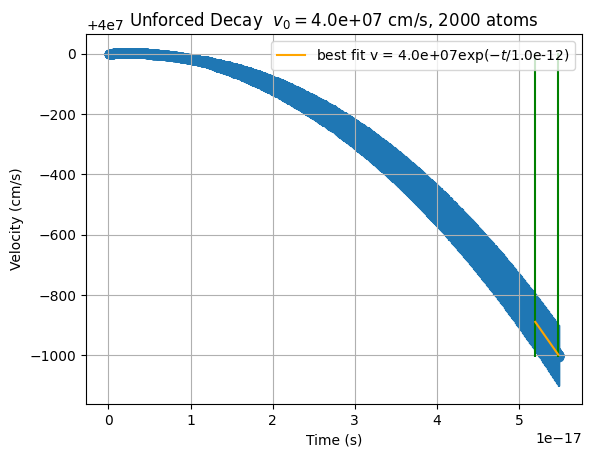

[4.18058893e-17 4.18177626e-17 4.18296359e-17 4.18415092e-17
 4.18533825e-17 4.18652558e-17 4.18771291e-17 4.18890024e-17
 4.19008757e-17 4.19127490e-17 4.19246223e-17 4.19364956e-17
 4.19483689e-17 4.19602422e-17 4.19721155e-17 4.19839888e-17
 4.19958621e-17 4.20077354e-17 4.20196087e-17 4.20314820e-17]
190
[1.71130881e-14 3.57735904e+02]


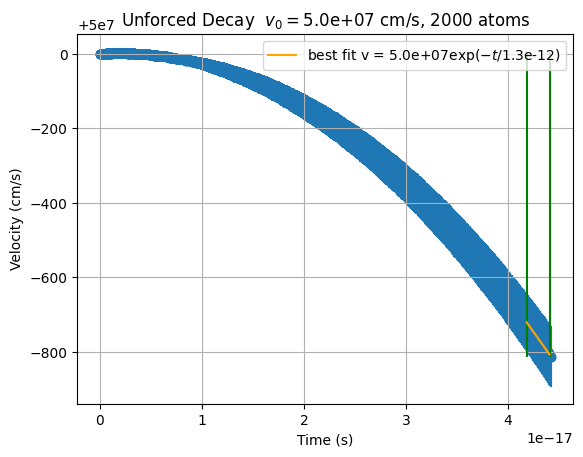

[1.02031053e-16 1.02040947e-16 1.02050842e-16 1.02060736e-16
 1.02070630e-16 1.02080525e-16 1.02090419e-16 1.02100314e-16
 1.02110208e-16 1.02120102e-16 1.02129997e-16 1.02139891e-16
 1.02149786e-16 1.02159680e-16 1.02169574e-16 1.02179469e-16
 1.02189363e-16 1.02199258e-16 1.02209152e-16 1.02219046e-16]
190
[1.71130881e-14 3.57735904e+02]


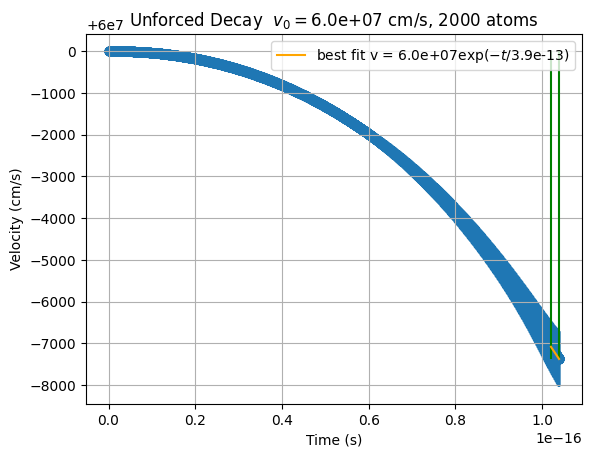

[8.69292250e-17 8.69377059e-17 8.69461868e-17 8.69546677e-17
 8.69631486e-17 8.69716295e-17 8.69801104e-17 8.69885913e-17
 8.69970722e-17 8.70055531e-17 8.70140340e-17 8.70225149e-17
 8.70309958e-17 8.70394767e-17 8.70479576e-17 8.70564385e-17
 8.70649194e-17 8.70734003e-17 8.70818812e-17 8.70903621e-17]
190
[1.71130881e-14 3.57735904e+02]


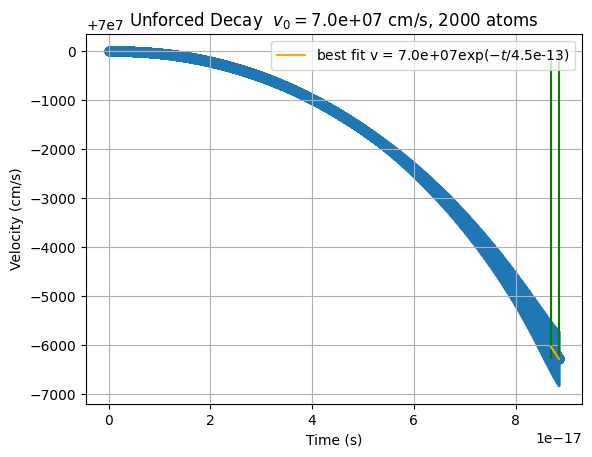

[3.01507104e-17 3.01581312e-17 3.01655520e-17 3.01729728e-17
 3.01803936e-17 3.01878144e-17 3.01952352e-17 3.02026560e-17
 3.02100768e-17 3.02174976e-17 3.02249184e-17 3.02323392e-17
 3.02397600e-17 3.02471808e-17 3.02546016e-17 3.02620224e-17
 3.02694432e-17 3.02768640e-17 3.02842848e-17 3.02917056e-17]
190
[1.71130881e-14 3.57735904e+02]


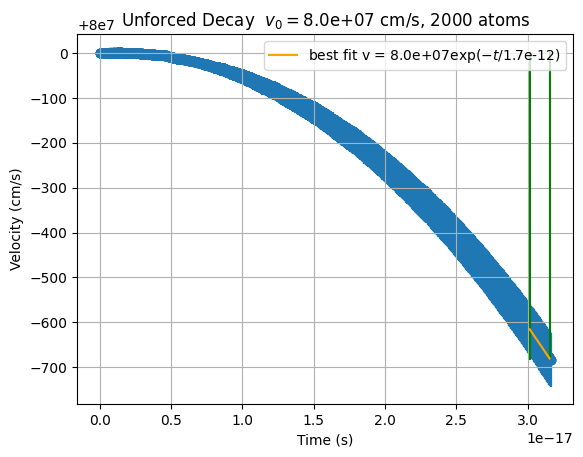

[6.80078530e-17 6.80144493e-17 6.80210456e-17 6.80276419e-17
 6.80342382e-17 6.80408345e-17 6.80474308e-17 6.80540271e-17
 6.80606234e-17 6.80672197e-17 6.80738160e-17 6.80804123e-17
 6.80870086e-17 6.80936049e-17 6.81002012e-17 6.81067975e-17
 6.81133938e-17 6.81199901e-17 6.81265864e-17 6.81331827e-17]
190


ValueError: 'x' and 'y' must have the same size

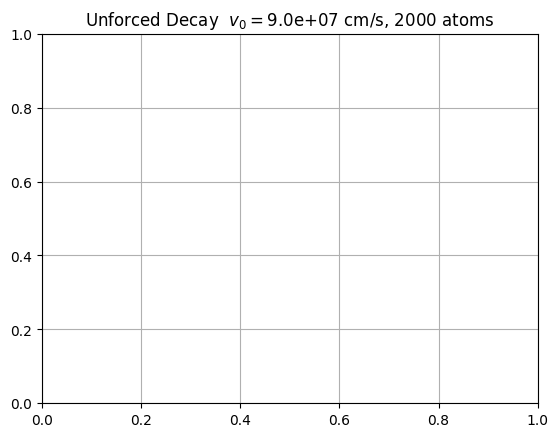

In [44]:
from scipy.optimize import curve_fit
frac = 0.005 #fraction of velocity change to trim
trimarr = np.zeros(len(flist),dtype=np.int64)
for i in range(len(flist)):
    trimarr[i] = np.min([np.argmin(np.abs(flist[i][:,0]-(1-frac)*flist[i][1,0])),len(flist[i][:,0])-200])
print(trimarr)

bestfits = np.zeros((vlen,5))
bestfits[:,0] = varr
colors2 = cm.rainbow(np.linspace(0, 1, vlen))
def exp(time,m,b):
    return b*np.exp(-time/m)
bestwindowarr = np.zeros(vlen,dtype=np.int64)

for i in range(vlen):
    dt = datalist[i][1,0]-datalist[i][0,0]
    plotlen = len(flist[i])
    timearr = np.arange(0,plotlen*dt,dt)
    starti = trimarr[i]
    windowsizes = np.arange(30,np.min([plotlen-starti,10000]),10)
    mguess = 1e-14
    bguess = flist[i][1,0]
    print(timearr[starti:starti+20])
    popt, pcov = curve_fit(exp,timearr[starti:starti+20],flist[i][starti:starti+20,0],sigma =flist[i][starti:starti+20,1],p0=[mguess,bguess],absolute_sigma=True)
    bestwindow = 10
    minerrors = np.sqrt(np.diag(pcov))[0]
    bestparams = popt
    besterr = np.sqrt(np.diag(pcov))
    for j in range(len(windowsizes)):
        popt, pcov = curve_fit(exp,timearr[starti:starti+windowsizes[j]],flist[i][starti:starti+windowsizes[j],0],sigma =flist[i][starti:starti+windowsizes[j],1],p0=popt,absolute_sigma=True)
        if minerrors> np.sqrt(np.diag(pcov))[0]:
            bestwindow = windowsizes[j]
            minerrors = np.sqrt(np.diag(pcov))[0]
            bestparams = popt
            besterr = np.sqrt(np.diag(pcov))
    bestfits[i,1:3] = bestparams
    bestfits[i,3:] = besterr
    print(bestwindow)
    plt.figure()
    plt.title(r"Unforced Decay  $v_0=${:.1e} cm/s, {} atoms".format(varr[i],atoms))
    plt.grid(zorder=0)
    plt.errorbar(timearr[1:],flist[i][1:,0],yerr=flist[i][1:,1],fmt="o",zorder=1)
    plt.vlines([timearr[starti],timearr[starti+bestwindow]],ymin=np.min(flist[i][1:,0]),ymax = np.max(flist[i][1:,0]),color="green")
    print(errors)
    plt.plot(timearr[starti:starti+bestwindow],exp(timearr[starti:starti+bestwindow],*popt),color="orange",zorder=10,label=r"best fit v = {:.1e}$\exp(-t/${:.1e}$)$".format(bestfits[i,2],bestfits[i,1]))
    # results[i,:] = [np.mean(flist[i][:,0]),((np.sum(np.square(flist[i][:,1])))**0.5)/len(flist[i][:,1])]
    plt.legend()
    plt.xlabel(r"Time (s)")
    plt.ylabel(r"Velocity (cm/s)")
    plt.show()

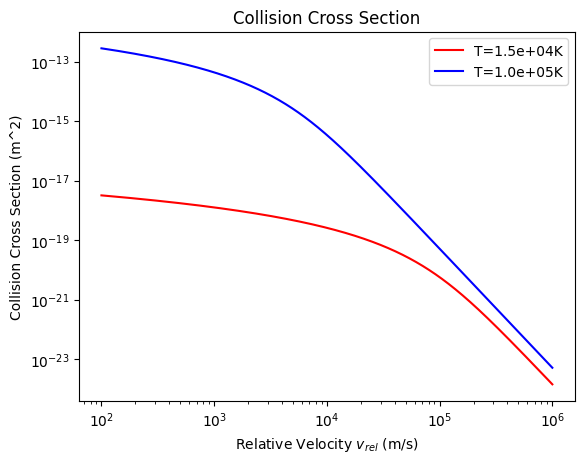

C:\Users\shaoq\AppData\Local\Temp\ipykernel_24040\2721982429.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq
C:\Users\shaoq\AppData\Local\Temp\ipykernel_24040\2721982429.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq


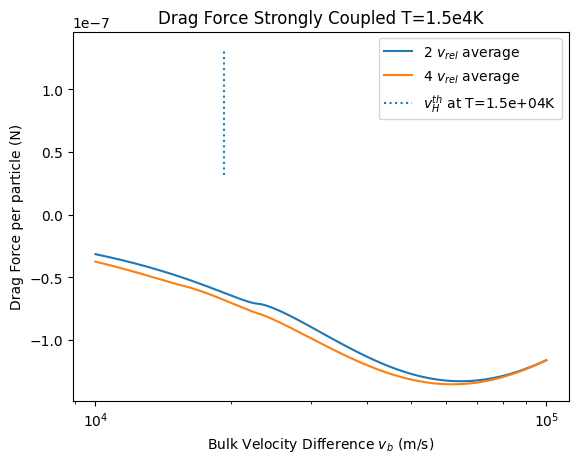

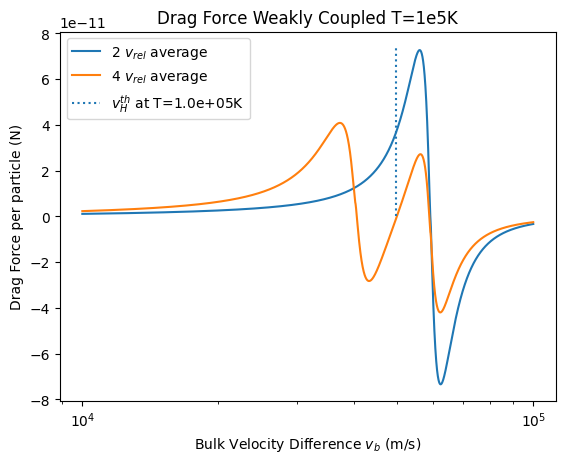

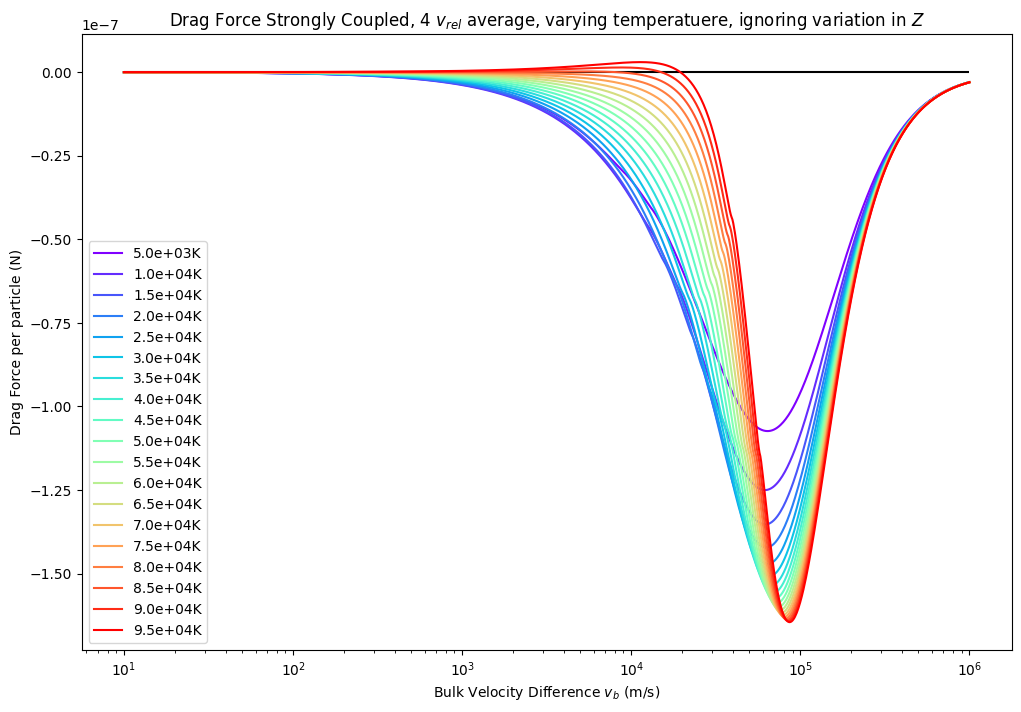

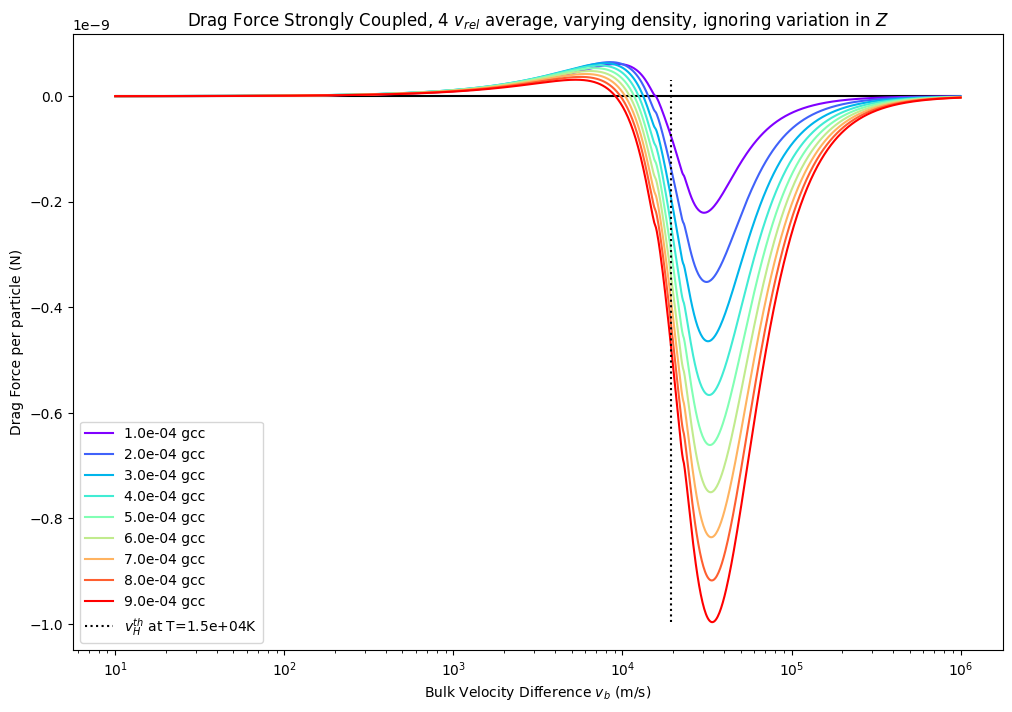

In [70]:
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
mh = 1.008*0.001/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12
#exp(-Ax)/x = B
#x = W(a/b)/a
def ccs2(vrel,vcom,T,gcc,z1=0.648,z2=3.84):# use kinetic energy difference
    ne =1e6* NA*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    #kinetic energy available is velocity relative to COM
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2
def FD4(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,1,-1,-1]
    signarr2 = [1,-1,1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),4))
    for i in range(4):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,vcom,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

def FD2(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,-1]
    signarr2 = [1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),2))
    for i in range(2):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,vcom,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

plt.xlabel(r"Relative Velocity $v_{rel}$ (m/s)")
plt.ylabel("Collision Cross Section (m^2)")
plt.title("Collision Cross Section")
CD=1
Tarr = np.array([15000,100000])
gccarr = [1,1e-6]
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
varr = np.logspace(4,5,10000)

varr3 = np.logspace(2,6,num=1000)
colors = ["red","blue"]
vtherm = np.sqrt(3*kb*Tarr/mh)
for i in range(len(Tarr)):
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    plt.plot(varr3,np.abs(ccs2(varr3,0,T,gcc,zh,zs)),label="T={:.1e}K".format(T),color=colors[i])
    # plt.vlines(vtherm[i],ymin=np.min(np.abs(FD(varr,CD,T,gcc,zh,zs))),ymax = np.max(np.abs(FD(varr,CD,T,gcc,zh,zs))),ls=":",label=r"$v_{{therm}}$ T={:.1e}K".format(T),color=colors[i])
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()


CD=1
vtherm = np.sqrt(3*kb*Tarr/mh)
titlearr = ["Drag Force Strongly Coupled T=1.5e4K","Drag Force Weakly Coupled T=1e5K"]
for i in range(len(Tarr)):
    plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
    plt.ylabel("Drag Force per particle (N)")
    plt.title(titlearr[i])
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force2,label=r"2 $v_{rel}$ average")
    plt.plot(varr,force4,label=r"4 $v_{rel}$ average")
    plt.vlines(vtherm[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T))
    plt.xscale("log")
    plt.legend()
    plt.show()

varr = np.logspace(1,6,1000)

plt.figure(figsize=(12,8))
plt.hlines(y=0,xmin=np.min(varr),xmax=np.max(varr),color="black")

plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
plt.ylabel("Drag Force per particle (N)")
plt.title("Drag Force Strongly Coupled, 4 $v_{rel}$ average, varying temperatuere, ignoring variation in $Z$")
Tarr2 = np.arange(5e3,1e5,5e3)
colors = cm.rainbow(np.linspace(0, 1, len(Tarr2)))
for i in range(len(Tarr2)):
    T = Tarr2[i]
    gcc = gccarr[0]
    zh=zharr[0]
    zs=zsarr[0]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force4,label="{:.1e}K".format(T),color=colors[i])
plt.xscale("log")
plt.legend()
plt.show()

varr = np.logspace(1,6,1000)
plt.figure(figsize=(12,8))
plt.hlines(y=0,xmin=np.min(varr),xmax=np.max(varr),color="black")
plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
plt.ylabel("Drag Force per particle (N)")
plt.title("Drag Force Strongly Coupled, 4 $v_{rel}$ average, varying density, ignoring variation in $Z$")
gccarr2 = np.arange(1e-4,1e-3,1e-4)
# gccarr2 = np.array([1e0,1e-1,1e-2,1e-3,1e-4,1e-5])
colors = cm.rainbow(np.linspace(0, 1, len(gccarr2)))
for i in range(len(gccarr2)):
    T = Tarr[0]
    gcc = gccarr2[i]
    zh=zharr[0]
    zs=zsarr[0]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force4,label="{:.1e} gcc".format(gcc),color=colors[i])
plt.vlines(vtherm[0],ymin=np.min(force4),ymax = np.max(force4),color="black",ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T))
# plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()



C:\Users\shaoq\AppData\Local\Temp\ipykernel_24040\2721982429.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq


[-1.14464222e+00  1.84177170e+04  5.12941927e-02]


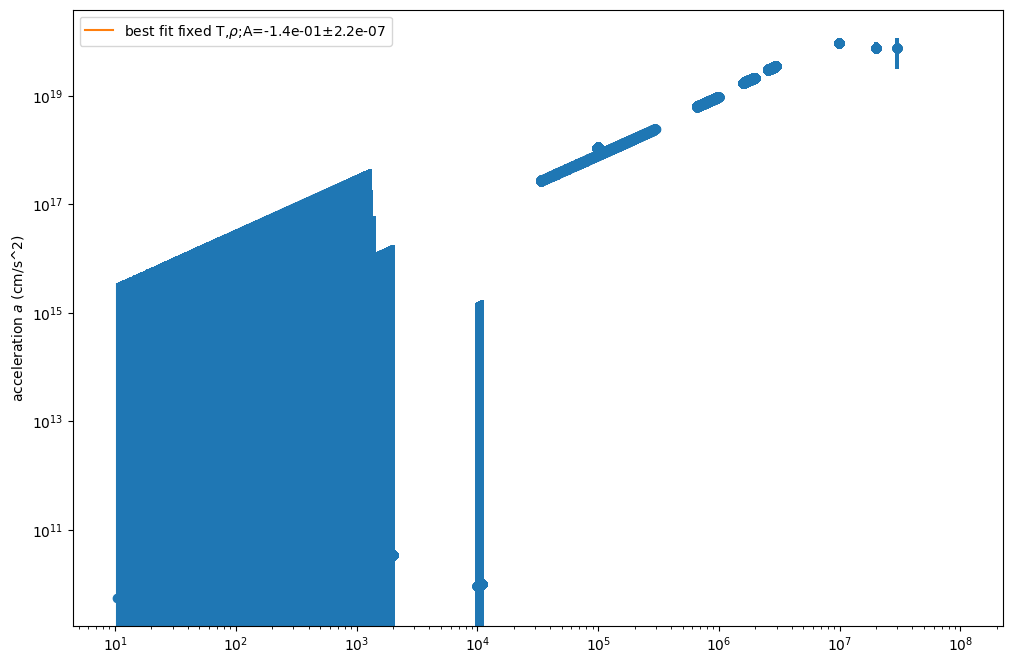

In [72]:
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
def fitFD4(vb,A):
    T = 15000
    gcc = 1
    zh = 0.648
    zs = 3.84
    ms = 0.0280855/6.02214076e23
    return 100*FD4(vb/100,A,T,gcc,zh,zs)/ms #convert newtons to cm/s^2
def fitFD4b(vb,A,T,gcc):
    zh = 0.648
    zs = 3.84
    ms = 0.0280855/6.02214076e23
    return 100*FD4(vb/100,A,T,gcc,zh,zs)/ms #convert newtons to cm/s^2
popt, pcov = curve_fit(fitFD4,fitarr[:,0],fitarr[:,1],sigma =fitarr[:,2],p0=[-1],absolute_sigma=True)
errors = np.sqrt(np.diag(pcov))
xarr = np.logspace(1,8,1000)
plt.figure(figsize=(12,8))
plt.errorbar(fitarr[:,0],fitarr[:,1],yerr=fitarr[:,2],fmt="o")
# plt.plot(xarr,fitFD4(xarr,*popt),label=r"best fit fixed T,$\rho$;A={:.1e}$\pm${:.1e}".format(popt[0],errors[0]))
plt.plot(xarr,fitFD4(xarr,1),label=r"best fit fixed T,$\rho$;A={:.1e}$\pm${:.1e}".format(popt[0],errors[0]))

popt, pcov = curve_fit(fitFD4b,fitarr[:,0],fitarr[:,1],sigma =fitarr[:,2],p0=[-1,15000,1],bounds=([-np.inf,0,0],[0,np.inf,np.inf]),absolute_sigma=True)
errors = np.sqrt(np.diag(pcov))
print(popt)
# plt.plot(xarr,fitFD4b(xarr,*popt),label=r"best fit free T={:.1e} K,$\rho$ = {:.1e} gcc A={:.1e}".format(popt[1],popt[2],popt[0]))
plt.xlabel(r"$v_b$ (cm/s)")
plt.ylabel(r"acceleration $a$ (cm/s^2)")

plt.legend()
plt.xlabel("")
plt.yscale("log")
plt.xscale("log")